# 04 — Classical Spectral Ranking Baseline

The question changes from notebook 03's *"is the correct molecule in the candidate pool?"* to:

> Can MS/MS spectral evidence rank the correct candidate near the top?

A **ranking** stage built on classical, interpretable baselines only -- no LightGBM, no
XGBoost, no DreaMS, no learned representations. Establishing what signal exists comes before
fitting a flexible model to it; learning-to-rank is notebook 05 (documented, not implemented,
in the final section here).

**Scope decisions, stated up front (not hidden):**
- Real MS/MS spectra in this dataset range from a handful of peaks to over 70,000 (p99 ~1,300)
  -- every spectrum is truncated to its `max_peaks_per_spectrum` most intense peaks before any
  similarity computation (standard practice; also the fix for an O(n_peaks²) blowup measured
  directly during this notebook's own development).
- Spectral similarity is far more expensive than notebook 03's mass lookups (~800 pairs/sec
  measured on this machine, vs. tens of thousands/sec for mass alone). Development ranking uses
  a `dev_ranking_sample_size`-query subsample (not notebook 03's full 60k) for tractability;
  test uses its full, real query set (only 1,213 spectra).
- Bin-width and intensity-normalization are each fixed at one measured-reasonable default
  (0.1 Da binned-cosine bins already L2-normalize; peak match tolerance 0.02 Da) rather than run
  as a multi-way study -- `casmi.spectra.preprocessing` already exposes the alternative
  normalizations for later exploration.
- Analogue-based (nearest-structural-neighbor) spectral features are explicitly deferred to
  notebook 05, per this milestone's own instructions.

**Two evaluation regimes, kept separate (never blended):**
- **KNOWN-SPECTRUM**: reference spectra may come from the SAME connectivity as the query
  (self-excluded). Measures spectral-library search performance.
- **UNSEEN-CONNECTIVITY**: reference spectra are restricted to OTHER CV folds -- the query's own
  true connectivity therefore has ZERO same-connectivity reference spectra, by construction.
  Measures whether spectral similarity to ANALOGUES carries signal for genuinely novel
  molecules. Poor direct-match performance here is the expected, correct result, not a bug.

In [1]:
import sys
import json
import time
NOTEBOOK_START_TIME = time.time()

from pathlib import Path

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "src").exists() and (REPO_ROOT.parent / "src").exists():
    REPO_ROOT = REPO_ROOT.parent
SRC_DIR = REPO_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from dataclasses import dataclass, field

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from casmi.paths import get_project_paths
from casmi.io.artifacts import load_artifact, artifact_fingerprint, save_artifact, artifact_is_valid
from casmi.io.parquet import load_rows_by_offset
from casmi.io.files import file_fingerprint
from casmi.candidates.cache import cached_dataframe, upstream_fingerprints
from casmi.spectra.preprocessing import remove_invalid_peaks, truncate_top_peaks
from casmi.spectra.library import (
    build_reference_index, known_spectrum_reference_ids, unseen_connectivity_reference_ids, assert_no_connectivity_leakage,
)
from casmi.ranking.features import compute_pair_spectral_scores, SPECTRAL_SCORE_PREFIXES, AGGREGATION_METHODS
from casmi.ranking.evaluation import rank_candidates, ranking_metrics, true_candidate_rank
from casmi.candidates.molecule import aggregate_candidates_to_molecule, molecule_candidate_summary
from casmi.validation.checks import CheckResult, summarize_checks
from casmi.validation.baseline_registry import register_baseline
from casmi.ranking.feature_policy import FeaturePolicy, DEFAULT_PROHIBITED_FEATURES, assert_no_prohibited_features

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)


@dataclass
class SpectralRankingConfig:
    dev_ranking_sample_size: int = 1000
    bin_width_da: float = 0.1
    peak_tol_da: float = 0.02
    max_peaks_per_spectrum: int = 100
    max_reference_spectra_per_candidate_per_fold: int = 5
    aggregation_methods: tuple = ("max", "top3_mean")
    k_values: tuple = (1, 5, 10, 25)
    seed: int = 42
    force_recompute: bool = False


config = SpectralRankingConfig()
config

SpectralRankingConfig(dev_ranking_sample_size=1000, bin_width_da=0.1, peak_tol_da=0.02, max_peaks_per_spectrum=100, max_reference_spectra_per_candidate_per_fold=5, aggregation_methods=('max', 'top3_mean'), k_values=(1, 5, 10, 25), seed=42, force_recompute=False)

In [2]:
paths = get_project_paths()
CG_INTERIM = paths.interim / "candidate_generation"
CG_PROCESSED = paths.processed / "candidate_generation"
RANK_INTERIM = paths.interim / "spectral_ranking"
RANK_PROCESSED = paths.processed / "spectral_ranking"
FIGURE_DIR = paths.figures / "spectral_ranking"
for d in (RANK_INTERIM, RANK_PROCESSED, FIGURE_DIR):
    d.mkdir(parents=True, exist_ok=True)

BASELINE_REGISTRY_PATH = paths.processed / "baseline_registry.json"

# Model-feature governance (hardening review section 2-3): reference-availability / candidate-
# source fields are provenance/diagnostic ONLY by default -- a flexible ranker (notebook 09)
# handed `has_reference_spectrum` directly could trivially learn "no reference -> true
# candidate" under the unseen-connectivity regime, since that's structurally guaranteed. This
# notebook only computes classical, hand-specified similarity scores (no learned model to feed
# yet), but the policy is defined here so every downstream notebook imports the SAME one.
RANKING_FEATURE_POLICY = FeaturePolicy(
    model_features=["abs_mass_error_ppm", "cosine_max", "cosine_top3_mean", "modified_cosine_max",
                     "modified_cosine_top3_mean", "peak_overlap_frac_max", "peak_overlap_frac_top3_mean",
                     "neutral_loss_cosine_max", "neutral_loss_cosine_top3_mean"],
    diagnostic_features=["n_reference_spectra", "has_reference_spectrum"],
    prohibited_features=DEFAULT_PROHIBITED_FEATURES,
)

checks = []


def local_fp(*names, directory=RANK_INTERIM):
    out = {}
    for name in names:
        fp = artifact_fingerprint(name, directory)
        if fp.startswith("missing:"):
            fp = artifact_fingerprint(name, RANK_PROCESSED)
        if fp.startswith("missing:"):
            fp = artifact_fingerprint(name, CG_INTERIM)
        if fp.startswith("missing:"):
            fp = artifact_fingerprint(name, CG_PROCESSED)
        out[name] = fp
    return out

## 2. Load notebook 03's frozen candidate-generation contract

**Never recomputes candidate generation.** If notebook 03 is `PROVISIONAL` (target recall not
reached), that's stated explicitly here, not silently treated as equivalent to `FROZEN`.

In [3]:
with open(CG_PROCESSED / "candidate_generation_contract.json") as f:
    contract = json.load(f)

print(f"candidate-generation contract status: {contract['status']}")
if contract["status"] != "FROZEN":
    print(f"NOTE: candidate generation is {contract['status']}, not FROZEN -- ranking numbers below inherit")
    print(f"      that ceiling (candidate recall < 100%) and should be read accordingly, not as a defect of ranking.")
print(json.dumps(contract["molecule_policy"], indent=2))

SELECTED_PPM = contract["molecule_policy"]["tolerance_ppm"]
checks.append(CheckResult("candidate contract loaded", True, f"status={contract['status']}, molecule policy={SELECTED_PPM}ppm"))

candidate-generation contract status: PROVISIONAL
NOTE: candidate generation is PROVISIONAL, not FROZEN -- ranking numbers below inherit
      that ceiling (candidate recall < 100%) and should be read accordingly, not as a defect of ranking.
{
  "aggregation": "union",
  "tolerance_ppm": 50,
  "test_like_recall_mean": 0.9941000000000001,
  "test_like_recall_std": 0.0005755432216610144,
  "median_candidate_count": 243.4,
  "p90_candidate_count": 674.4599999999999,
  "seeds": [
    42,
    43,
    44,
    45,
    46
  ]
}


In [4]:
molecule_metadata = load_artifact("molecule_metadata")
train_meta = load_artifact("train_spectrum_metadata")
test_meta = load_artifact("test_spectrum_metadata")
connectivity_folds = load_artifact("connectivity_folds")

dev_queries = pd.read_parquet(CG_INTERIM / "dev_queries.parquet")
test_queries = pd.read_parquet(CG_INTERIM / "test_queries.parquet")
pool_dev_max = pd.read_parquet(CG_INTERIM / "candidate_pool_dev_max50ppm.parquet")
pool_test_max = pd.read_parquet(CG_INTERIM / "candidate_pool_test_max50ppm.parquet")

pool_fp_current = file_fingerprint(CG_INTERIM / "candidate_pool_dev_max50ppm.parquet")
pool_fp_expected = contract.get("library_fingerprint")  # sanity spot-check, not a strict equality requirement
print(f"molecule_metadata {molecule_metadata.shape}, train_spectrum_metadata {train_meta.shape}")
print(f"dev_queries {dev_queries.shape}, test_queries {test_queries.shape}")
print(f"pool_dev_max {pool_dev_max.shape}, pool_test_max {pool_test_max.shape}")
checks.append(CheckResult("candidate pool fingerprint valid", pool_fp_current is not None and not pool_fp_current.startswith("missing:"),
                           "candidate_pool_dev_max50ppm.parquet resolved to a real fingerprint"))

molecule_metadata (274195, 8), train_spectrum_metadata (2539608, 27)
dev_queries (60000, 12), test_queries (1213, 7)
pool_dev_max (15192350, 12), pool_test_max (471173, 10)


## 3. Development ranking sample

A `config.dev_ranking_sample_size`-query subsample of notebook 03's `dev_queries` (see Section
1's scope note on why: spectral similarity is far more expensive than mass lookups).

In [5]:
def _build_dev_ranking_queries():
    return dev_queries.sample(min(config.dev_ranking_sample_size, len(dev_queries)), random_state=config.seed).reset_index(drop=True)


dev_ranking_queries, _, _ = cached_dataframe(
    "dev_ranking_queries", RANK_INTERIM, _build_dev_ranking_queries, config=config, force=config.force_recompute,
    input_fingerprints=local_fp("dev_queries", directory=CG_INTERIM),
    description="Subsample of notebook 03's dev_queries used for spectral ranking (tractability)",
)

pool_dev_ranking = pool_dev_max[
    pool_dev_max["query_id"].isin(set(dev_ranking_queries["query_id"])) & (pool_dev_max["abs_mass_error_ppm"] <= SELECTED_PPM)
].reset_index(drop=True)
print(f"dev_ranking_queries: {len(dev_ranking_queries):,} queries")
print(f"pool_dev_ranking (@ {SELECTED_PPM}ppm): {len(pool_dev_ranking):,} candidate pairs "
      f"({len(pool_dev_ranking) / len(dev_ranking_queries):.0f} candidates/query avg)")

[CACHE HIT] dev_ranking_queries <- C:\Users\myben\OneDrive\Documents\Enveda\data\interim\spectral_ranking\dev_ranking_queries.parquet


dev_ranking_queries: 1,000 queries
pool_dev_ranking (@ 50ppm): 248,027 candidate pairs (248 candidates/query avg)


## 4. Define the two evaluation regimes

`reference_index` is the raw (unrestricted) connectivity -> spectrum-id lookup; each regime
filters it differently at scoring time (Section 6). The leakage assertion for the
unseen-connectivity regime is checked HERE, structurally, not left to be discovered later.

In [6]:
reference_index = build_reference_index(train_meta)
connectivity_to_fold = connectivity_folds.set_index("connectivity_key")["fold"].to_dict()
print(f"reference_index: {len(reference_index):,} connectivities")

# structural leakage check: for every dev-ranking query, its OWN fold's connectivity must
# contribute ZERO reference spectra under the unseen-connectivity regime.
example_query = dev_ranking_queries.iloc[0]
example_refs = unseen_connectivity_reference_ids(reference_index, example_query["true_connectivity_key"],
                                                   query_fold=example_query["fold"], connectivity_to_fold=connectivity_to_fold)
assert len(example_refs) == 0, "a query's own true connectivity must have zero unseen-connectivity reference spectra"
checks.append(CheckResult("no query-spectrum self-match", True, "known-spectrum regime excludes exact query spectrum id by construction"))
checks.append(CheckResult("unseen-connectivity leakage = 0", len(example_refs) == 0,
                           "verified: a query's own true connectivity yields 0 unseen-connectivity reference spectra"))
print("Structural leakage check PASSED: a query's own connectivity has 0 reference spectra under the unseen-connectivity regime.")

reference_index: 274,195 connectivities
Structural leakage check PASSED: a query's own connectivity has 0 reference spectra under the unseen-connectivity regime.


## 5. Load raw peak arrays (dev + test queries and their candidate reference spectra)

One combined, memory-bounded `load_rows_by_offset` call (`casmi.io.parquet`) per raw file --
scattered offsets already touch nearly every row group once sample size passes a few hundred,
so batching all needed offsets into ONE call (instead of one per query) avoids paying that
near-full-file-scan cost multiple times. Every loaded spectrum is immediately cleaned
(`remove_invalid_peaks`) and capped at `config.max_peaks_per_spectrum` (`truncate_top_peaks`).

In [7]:
def offset_of(spectrum_id):
    return int(spectrum_id.split("_")[1])


def _reference_ids_per_fold_capped(connectivity_key, cap):
    """Up to `cap` reference spectrum ids from EACH fold for `connectivity_key` -- not just
    the first `cap` overall -- so both regimes have a fair chance to find references (a
    connectivity's first few spectra in file order could otherwise all land in one fold)."""
    ids = reference_index.get(connectivity_key, [])
    if not ids:
        return []
    id_df = pd.DataFrame({"id": ids})
    id_df["fold"] = id_df["id"].map(lambda i: connectivity_to_fold.get(connectivity_key))
    out = []
    for _, g in id_df.groupby("fold"):
        out.extend(g["id"].head(cap).tolist())
    return out


t0 = time.time()
cap = config.max_reference_spectra_per_candidate_per_fold
dev_candidate_keys = pool_dev_ranking["candidate_connectivity_key"].unique()
dev_ref_ids_needed = set()
for key in dev_candidate_keys:
    dev_ref_ids_needed.update(reference_index.get(key, [])[: cap * 5])  # cap*5: room for up to `cap` per fold across 5 folds

dev_query_offsets = set(dev_ranking_queries["query_id"].apply(offset_of))
dev_ref_offsets = set(offset_of(i) for i in dev_ref_ids_needed)
dev_all_offsets = dev_query_offsets | dev_ref_offsets
print(f"dev: {len(dev_query_offsets):,} query offsets + {len(dev_ref_offsets):,} reference offsets = {len(dev_all_offsets):,} total")

dev: 1,000 query offsets + 1,013,904 reference offsets = 1,014,136 total


In [8]:
def _load_peaks_by_offset(path, offsets):
    raw = load_rows_by_offset(path, ["ms2_mzs", "ms2_normalized_intensities", "precursor_mz"], list(offsets))
    raw = raw.rename(columns={"_row_offset": "row_offset"})
    out = {}
    for row in raw.itertuples(index=False):
        mzs, ints = remove_invalid_peaks(row.ms2_mzs, row.ms2_normalized_intensities)
        mzs, ints = truncate_top_peaks(mzs, ints, max_peaks=config.max_peaks_per_spectrum)
        out[row.row_offset] = {"mzs": mzs, "intensities": ints, "precursor_mz": row.precursor_mz}
    return out


# WARM-CACHE FIX (hardening review section 62-64): only pay the near-full-file-scan peak-I/O
# cost if the pair-feature tables that would consume it are NOT already validly cached -- a
# warm rerun should never re-load >1M peak rows just to discover a cache hit two cells later.
dev_pairs_fp = local_fp("dev_ranking_queries")
dev_pairs_cached = (not config.force_recompute
                     and artifact_is_valid("pair_features_dev_known_spectrum", RANK_INTERIM, config=config, input_fingerprints=dev_pairs_fp)
                     and artifact_is_valid("pair_features_dev_unseen_connectivity", RANK_INTERIM, config=config, input_fingerprints=dev_pairs_fp))

if dev_pairs_cached:
    print(f"[CACHE HIT] both dev pair-feature tables already valid -- skipping {len(dev_all_offsets):,}-row peak I/O entirely")
    dev_peaks_by_offset = {}
else:
    dev_peaks_by_offset = _load_peaks_by_offset(paths.train, dev_all_offsets)
    print(f"[CACHE MISS] loaded {len(dev_peaks_by_offset):,} dev-side peak rows in {time.time() - t0:.1f}s")
checks.append(CheckResult("spectrum representations cached", dev_pairs_cached or len(dev_peaks_by_offset) > 0,
                           "skipped I/O on warm rerun" if dev_pairs_cached else f"{len(dev_peaks_by_offset):,} spectra loaded and peak-capped"))

[CACHE HIT] both dev pair-feature tables already valid -- skipping 1,014,136-row peak I/O entirely


## 6. Build pair-level spectral features (both regimes)

One row per (query, candidate) pair, adding `SPECTRAL_SCORE_PREFIXES x AGGREGATION_METHODS`
spectral scores (`casmi.ranking.features.compute_pair_spectral_scores`) on top of notebook 03's
mass evidence already in the pool. `regime_reference_fn(candidate_key, query_row) -> [spectrum_id, ...]`
is the only thing that differs between the two regimes below.

In [9]:
def build_pair_features(pool, queries, peaks_by_offset, regime_reference_fn, max_refs):
    pool_by_query = {qid: g for qid, g in pool.groupby("query_id")}
    query_by_id = {row.query_id: row for row in queries.itertuples(index=False)}

    records = []
    n_skipped_no_query_peaks = 0
    for query_row in queries.itertuples(index=False):
        q_offset = offset_of(query_row.query_id)
        if q_offset not in peaks_by_offset:
            n_skipped_no_query_peaks += 1
            continue
        q_peaks = peaks_by_offset[q_offset]
        my_candidates = pool_by_query.get(query_row.query_id)
        if my_candidates is None:
            continue
        for cand_row in my_candidates.itertuples(index=False):
            ref_ids = regime_reference_fn(cand_row.candidate_connectivity_key, query_row)[:max_refs]
            ref_peaks_list = [peaks_by_offset[offset_of(rid)] for rid in ref_ids if offset_of(rid) in peaks_by_offset]
            scores = compute_pair_spectral_scores(q_peaks, ref_peaks_list, bin_width=config.bin_width_da, peak_tol_da=config.peak_tol_da)
            record = {
                "query_id": cand_row.query_id, "candidate_connectivity_key": cand_row.candidate_connectivity_key,
                "abs_mass_error_ppm": cand_row.abs_mass_error_ppm,
                "is_true_candidate": getattr(cand_row, "is_true_candidate", False),
            }
            record.update(scores)
            records.append(record)
    if n_skipped_no_query_peaks:
        print(f"  ({n_skipped_no_query_peaks} queries skipped -- no loadable peak data)")
    return pd.DataFrame.from_records(records)


def known_spectrum_ref_fn(candidate_key, query_row):
    return known_spectrum_reference_ids(reference_index, candidate_key, exclude_spectrum_id=query_row.query_id)


def unseen_connectivity_ref_fn(candidate_key, query_row):
    return unseen_connectivity_reference_ids(reference_index, candidate_key, query_fold=query_row.fold, connectivity_to_fold=connectivity_to_fold)

In [10]:
def _build_dev_pairs_known():
    t0 = time.time()
    df = build_pair_features(pool_dev_ranking, dev_ranking_queries, dev_peaks_by_offset, known_spectrum_ref_fn, config.max_reference_spectra_per_candidate_per_fold)
    print(f"  known-spectrum: {len(df):,} pairs in {time.time() - t0:.1f}s ({len(df) / max(time.time() - t0, 1e-6):.0f} pairs/sec)")
    return df


pair_features_dev_known, _, _ = cached_dataframe(
    "pair_features_dev_known_spectrum", RANK_INTERIM, _build_dev_pairs_known, config=config, force=config.force_recompute,
    input_fingerprints=local_fp("dev_ranking_queries"),
    description="Dev pair-level features, KNOWN-SPECTRUM regime (same-connectivity references allowed, self-excluded)",
)
print(f"pair_features_dev_known_spectrum: {pair_features_dev_known.shape}")
checks.append(CheckResult("known-spectrum baseline complete", len(pair_features_dev_known) > 0, f"{len(pair_features_dev_known):,} pairs"))

[CACHE HIT] pair_features_dev_known_spectrum <- C:\Users\myben\OneDrive\Documents\Enveda\data\interim\spectral_ranking\pair_features_dev_known_spectrum.parquet
pair_features_dev_known_spectrum: (248027, 14)


In [11]:
def _build_dev_pairs_unseen():
    t0 = time.time()
    df = build_pair_features(pool_dev_ranking, dev_ranking_queries, dev_peaks_by_offset, unseen_connectivity_ref_fn, config.max_reference_spectra_per_candidate_per_fold)
    print(f"  unseen-connectivity: {len(df):,} pairs in {time.time() - t0:.1f}s ({len(df) / max(time.time() - t0, 1e-6):.0f} pairs/sec)")
    return df


pair_features_dev_unseen, _, _ = cached_dataframe(
    "pair_features_dev_unseen_connectivity", RANK_INTERIM, _build_dev_pairs_unseen, config=config, force=config.force_recompute,
    input_fingerprints=local_fp("dev_ranking_queries"),
    description="Dev pair-level features, UNSEEN-CONNECTIVITY regime (references restricted to other CV folds)",
)
print(f"pair_features_dev_unseen_connectivity: {pair_features_dev_unseen.shape}")

# structural re-check at full scale: every TRUE candidate row under this regime must show has_reference_spectrum=False
true_rows_unseen = pair_features_dev_unseen[pair_features_dev_unseen["is_true_candidate"]]
assert not true_rows_unseen["has_reference_spectrum"].any(), "a true candidate should NEVER have a same-fold reference spectrum under unseen-connectivity"
print(f"Verified at full scale: {len(true_rows_unseen):,} / {len(true_rows_unseen):,} true-candidate rows have has_reference_spectrum=False (expected, by construction).")
checks.append(CheckResult("unseen-connectivity baseline complete", len(pair_features_dev_unseen) > 0, f"{len(pair_features_dev_unseen):,} pairs"))

[CACHE HIT] pair_features_dev_unseen_connectivity <- C:\Users\myben\OneDrive\Documents\Enveda\data\interim\spectral_ranking\pair_features_dev_unseen_connectivity.parquet
pair_features_dev_unseen_connectivity: (248027, 14)
Verified at full scale: 980 / 980 true-candidate rows have has_reference_spectrum=False (expected, by construction).


### Feature-policy governance check

`has_reference_spectrum`/`n_reference_spectra` are exactly the shortcut the unseen-connectivity
structural check above demonstrates: they'd perfectly predict `is_true_candidate` under that
regime for reasons having nothing to do with spectral evidence. Demonstrated here (this
notebook trains no model yet -- notebook 09 will import the SAME `RANKING_FEATURE_POLICY`).

In [12]:
try:
    assert_no_prohibited_features(pair_features_dev_unseen, RANKING_FEATURE_POLICY)
    print("UNEXPECTED: raw pair table should contain prohibited fields -- policy check did not fire")
except AssertionError as e:
    print(f"[EXPECTED] raw pair table correctly REJECTED by feature-policy check: {e}")

model_ready_columns = [c for c in RANKING_FEATURE_POLICY.model_features if c in pair_features_dev_unseen.columns]
model_ready_df = pair_features_dev_unseen[model_ready_columns]
assert_no_prohibited_features(model_ready_df, RANKING_FEATURE_POLICY)  # should NOT raise
print(f"model-ready column subset ({len(model_ready_columns)} columns) correctly PASSES the same check.")
checks.append(CheckResult("feature policy governance wired", True, "assert_no_prohibited_features fires on raw pair table, passes on model-ready subset"))

[EXPECTED] raw pair table correctly REJECTED by feature-policy check: prohibited (leakage-prone) features present in model input: ['has_reference_spectrum', 'n_reference_spectra']
model-ready column subset (9 columns) correctly PASSES the same check.


## 7. Single-signal ranking baselines

**Four distinct quantities, never conflated (hardening review section 4):**
- `retrieval_recall` -- true connectivity exists in the candidate pool AT ALL (signal-independent
  within a regime: mass-based candidate generation doesn't know which spectral signal will
  later be computed).
- `target_score_coverage` -- true candidate is IN the pool AND received a usable (non-NaN) score
  for THIS SPECIFIC signal (e.g. mass_only is virtually always defined; cosine_max is NaN
  whenever the candidate has zero reference spectra).
- `conditional_mrr_at_25` -- ranking quality given the target has a usable score for this signal
  (denominator = only those queries).
- `end_to_end_mrr_at_25` -- ALL intended queries; a missing target OR a target with no usable
  score for this signal both contribute 0 (denominator = every query, never dropped).

In [13]:
SIGNALS = {
    "mass_only": ("abs_mass_error_ppm", True),   # (score_col, ascending) -- ascending=True means LOWER is better
    "cosine_max": ("cosine_max", False),
    "modified_cosine_max": ("modified_cosine_max", False),
    "peak_overlap_max": ("peak_overlap_frac_max", False),
    "neutral_loss_cosine_max": ("neutral_loss_cosine_max", False),
}


def evaluate_all_signals(pair_df, all_query_ids, regime_name):
    true_rows = pair_df[pair_df["is_true_candidate"]]
    retrieval_recall = len(set(true_rows["query_id"]) & set(all_query_ids)) / len(all_query_ids)

    rows = []
    for signal_name, (score_col, ascending) in SIGNALS.items():
        target_scored_queries = set(true_rows.dropna(subset=[score_col])["query_id"]) & set(all_query_ids)
        target_score_coverage = len(target_scored_queries) / len(all_query_ids)

        scored = pair_df.dropna(subset=[score_col]).copy()
        scored["score"] = -scored[score_col] if ascending else scored[score_col]
        ranked = rank_candidates(scored, score_col="score", ascending=False)
        metrics = ranking_metrics(ranked, all_query_ids, k_values=config.k_values)
        rows.append({"regime": regime_name, "signal": signal_name,
                      "retrieval_recall": retrieval_recall, "target_score_coverage": target_score_coverage,
                      "conditional_mrr_at_25": metrics["conditional"]["mrr_at_25"],
                      "conditional_hit_at_1": metrics["conditional"]["hit_at_1"],
                      "conditional_median_rank": metrics["conditional"]["median_rank"],
                      "end_to_end_mrr_at_25": metrics["end_to_end"]["mrr_at_25"],
                      "end_to_end_hit_at_1": metrics["end_to_end"]["hit_at_1"],
                      "end_to_end_hit_at_25": metrics["end_to_end"]["hit_at_25"]})
    return pd.DataFrame(rows)


all_dev_query_ids = dev_ranking_queries["query_id"].tolist()
signal_comparison_known = evaluate_all_signals(pair_features_dev_known, all_dev_query_ids, "known_spectrum")
signal_comparison_unseen = evaluate_all_signals(pair_features_dev_unseen, all_dev_query_ids, "unseen_connectivity")
signal_comparison = pd.concat([signal_comparison_known, signal_comparison_unseen], ignore_index=True)

_, _, _ = cached_dataframe(
    "spectrum_baseline_metrics", RANK_PROCESSED, build_fn=lambda: signal_comparison,
    config=config, force=config.force_recompute, input_fingerprints=local_fp("pair_features_dev_known_spectrum", "pair_features_dev_unseen_connectivity"),
    description="Single-signal ranking metrics (mass-only + 4 spectral signals), both regimes -- retrieval_recall/target_score_coverage/conditional/end-to-end kept separate",
)
display(signal_comparison)

[CACHE HIT] spectrum_baseline_metrics <- C:\Users\myben\OneDrive\Documents\Enveda\data\processed\spectral_ranking\spectrum_baseline_metrics.parquet


,regime,signal,retrieval_recall,target_score_coverage,conditional_mrr_at_25,conditional_hit_at_1,conditional_median_rank,end_to_end_mrr_at_25,end_to_end_hit_at_1,end_to_end_hit_at_25
0,known_spectrum,mass_only,0.98,0.980,0.295864,0.170408,7.0,0.289946,0.167,0.747
1,known_spectrum,cosine_max,0.98,0.976,0.603395,0.513320,1.0,0.588913,0.501,0.820
2,known_spectrum,modified_cosine_max,0.98,0.976,0.623103,0.531762,1.0,0.608148,0.519,0.832
3,known_spectrum,peak_overlap_max,0.98,0.976,0.707829,0.651639,1.0,0.690841,0.636,0.844
4,known_spectrum,neutral_loss_cosine_max,0.98,0.976,0.587745,0.498975,2.0,0.573639,0.487,0.806
5,unseen_connectivity,mass_only,0.98,0.980,0.295864,0.170408,7.0,0.289946,0.167,0.747
6,unseen_connectivity,cosine_max,0.98,0.000,NaN,NaN,NaN,0.000000,0.000,0.000
7,unseen_connectivity,modified_cosine_max,0.98,0.000,NaN,NaN,NaN,0.000000,0.000,0.000
8,unseen_connectivity,peak_overlap_max,0.98,0.000,NaN,NaN,NaN,0.000000,0.000,0.000
9,unseen_connectivity,neutral_loss_cosine_max,0.98,0.000,NaN,NaN,NaN,0.000000,0.000,0.000


### Failure-stage diagnostic table

The previous version's "24 missing targets" conflated two different things. Separated here
(hardening review section 5) using `casmi.validation.test_like.failure_stage_table`.

In [14]:
from casmi.validation.test_like import failure_stage_table

dev_ranking_summary = dev_summary[dev_summary["query_id"].isin(set(all_dev_query_ids))] if "dev_summary" in dir() else None
# dev_summary (notebook 03's per-query mass-error table) isn't loaded in this notebook by
# default; reconstruct the minimal columns failure_stage_table needs directly from what we have.
query_candidate_summary_path = CG_PROCESSED / "query_candidate_summary.parquet"
qcs = pd.read_parquet(query_candidate_summary_path)
qcs_ranking = qcs[qcs["query_id"].isin(set(all_dev_query_ids))]

stage_table = failure_stage_table(qcs_ranking, pair_features_dev_known, all_dev_query_ids, tolerance_ppm=SELECTED_PPM)
display(stage_table)
_, _, _ = cached_dataframe(
    "failure_stage_table", RANK_PROCESSED, build_fn=lambda: stage_table,
    config=config, force=config.force_recompute, input_fingerprints=local_fp("pair_features_dev_known_spectrum"),
    description="Missing-from-pool vs retrieved-but-unscored vs retrieved-and-scored, dev ranking sample",
)

,failure_stage,count,fraction
0,missing from candidate pool,20,0.020
1,"candidate retrieved, direct reference unavailable",4,0.004
2,candidate retrieved and scored,976,0.976


[CACHE HIT] failure_stage_table <- C:\Users\myben\OneDrive\Documents\Enveda\data\processed\spectral_ranking\failure_stage_table.parquet


## 8. Simple score/rank fusion

A small, transparent grid -- NOT dozens of tuned weights -- evaluated only on development.
`combined_score = cosine_max - λ * abs_mass_error_ppm`, plus a pure rank-fusion baseline
(`mass_rank + spectral_rank`, lower is better). Best chosen by measured end-to-end MRR@25.

In [15]:
def evaluate_fusion(pair_df, all_query_ids, lambdas=(0.0, 0.001, 0.01, 0.1, 1.0)):
    rows = []
    base = pair_df.dropna(subset=["abs_mass_error_ppm"]).copy()
    base["cosine_max_filled"] = base["cosine_max"].fillna(0.0)
    for lam in lambdas:
        base["combined_score"] = base["cosine_max_filled"] - lam * base["abs_mass_error_ppm"]
        ranked = rank_candidates(base, score_col="combined_score", ascending=False)
        m = ranking_metrics(ranked, all_query_ids, k_values=config.k_values)
        rows.append({"method": f"cosine_minus_{lam}x_ppm", "end_to_end_mrr_at_25": m["end_to_end"]["mrr_at_25"],
                     "end_to_end_hit_at_1": m["end_to_end"]["hit_at_1"], "end_to_end_hit_at_25": m["end_to_end"]["hit_at_25"]})

    # pure rank fusion: mass_rank (ascending ppm) + spectral_rank (descending cosine), lower sum = better
    mass_ranked = rank_candidates(base.assign(score=-base["abs_mass_error_ppm"]), score_col="score", ascending=False).rename(columns={"rank": "mass_rank"})
    spec_ranked = rank_candidates(base.assign(score=base["cosine_max_filled"]), score_col="score", ascending=False)["rank"]
    fusion_df = mass_ranked.copy()
    fusion_df["rank_sum"] = mass_ranked["mass_rank"].to_numpy() + spec_ranked.to_numpy()
    ranked_fusion = rank_candidates(fusion_df.assign(score=-fusion_df["rank_sum"]), score_col="score", ascending=False)
    m = ranking_metrics(ranked_fusion, all_query_ids, k_values=config.k_values)
    rows.append({"method": "rank_fusion(mass+cosine)", "end_to_end_mrr_at_25": m["end_to_end"]["mrr_at_25"],
                 "end_to_end_hit_at_1": m["end_to_end"]["hit_at_1"], "end_to_end_hit_at_25": m["end_to_end"]["hit_at_25"]})
    return pd.DataFrame(rows)


fusion_known = evaluate_fusion(pair_features_dev_known, all_dev_query_ids)
print("KNOWN-SPECTRUM regime fusion grid:")
display(fusion_known)
best_fusion_row = fusion_known.sort_values("end_to_end_mrr_at_25", ascending=False).iloc[0]
print(f"\nbest by measured end-to-end MRR@25: {best_fusion_row['method']} ({best_fusion_row['end_to_end_mrr_at_25']:.4f})")

KNOWN-SPECTRUM regime fusion grid:


,method,end_to_end_mrr_at_25,end_to_end_hit_at_1,end_to_end_hit_at_25
0,cosine_minus_0.0x_ppm,0.590485,0.502,0.823
1,cosine_minus_0.001x_ppm,0.613956,0.519,0.854
2,cosine_minus_0.01x_ppm,0.660005,0.573,0.894
3,cosine_minus_0.1x_ppm,0.683065,0.590,0.928
4,cosine_minus_1.0x_ppm,0.623509,0.513,0.918
5,rank_fusion(mass+cosine),0.520970,0.394,0.876



best by measured end-to-end MRR@25: cosine_minus_0.1x_ppm (0.6831)


## 9. Test candidate pair features (full test set)

Test has no known true connectivity (the prediction target) -- no recall/MRR numbers here,
only the spectral scores themselves, saved for downstream (notebook 05) use. Test's own row
offsets within `test.parquet` are looked up by `spectrum_id` (test keeps its original id,
unlike train's minted `train_<offset>`), not parsed the way `offset_of` parses train ids.

In [16]:
test_spectrum_offset = {sid: i for i, sid in enumerate(test_meta["spectrum_id"])}
pool_test_ranking = pool_test_max[pool_test_max["abs_mass_error_ppm"] <= SELECTED_PPM].reset_index(drop=True)
print(f"pool_test_ranking (@ {SELECTED_PPM}ppm): {len(pool_test_ranking):,} candidate pairs "
      f"({len(pool_test_ranking) / len(test_queries):.0f} candidates/query avg)")

test_pairs_fp = local_fp("test_queries", directory=CG_INTERIM)
test_pairs_cached = not config.force_recompute and artifact_is_valid("pair_features_test", RANK_INTERIM, config=config, input_fingerprints=test_pairs_fp)

train_peaks_by_offset = dict(dev_peaks_by_offset)
if test_pairs_cached:
    print("[CACHE HIT] pair_features_test already valid -- skipping test-side peak I/O entirely")
    test_peaks_by_offset = {}
else:
    t0 = time.time()
    test_candidate_keys = pool_test_ranking["candidate_connectivity_key"].unique()
    test_ref_ids_needed = set()
    for key in test_candidate_keys:
        test_ref_ids_needed.update(reference_index.get(key, [])[: config.max_reference_spectra_per_candidate_per_fold * 5])
    new_train_offsets = set(offset_of(i) for i in test_ref_ids_needed) - set(train_peaks_by_offset.keys())
    print(f"test needs {len(new_train_offsets):,} NEW train reference offsets beyond what dev already loaded")

    if new_train_offsets:
        train_peaks_by_offset.update(_load_peaks_by_offset(paths.train, new_train_offsets))
    test_peaks_by_offset = _load_peaks_by_offset(paths.test, set(test_spectrum_offset.values()))
    print(f"[CACHE MISS] loaded {len(test_peaks_by_offset):,} test-side + {len(train_peaks_by_offset):,} total train-side peak rows in {time.time() - t0:.1f}s")

pool_test_ranking (@ 50ppm): 471,173 candidate pairs (388 candidates/query avg)
[CACHE HIT] pair_features_test already valid -- skipping test-side peak I/O entirely


In [17]:
def test_ref_fn(candidate_key, query_row):
    # unrestricted: no fold concept for test, no self-exclusion needed (test spectra are
    # disjoint from train by construction).
    return reference_index.get(candidate_key, [])


def _build_test_pairs():
    t0 = time.time()
    # build_pair_features expects offset_of(query_id) to resolve via the train-style parser;
    # test uses a spectrum_id->offset lookup instead, so query peaks are substituted directly.
    pool_by_query = {qid: g for qid, g in pool_test_ranking.groupby("query_id")}
    records = []
    for query_row in test_queries.itertuples(index=False):
        q_off = test_spectrum_offset.get(query_row.query_id)
        if q_off is None or q_off not in test_peaks_by_offset:
            continue
        q_peaks = test_peaks_by_offset[q_off]
        my_candidates = pool_by_query.get(query_row.query_id)
        if my_candidates is None:
            continue
        for cand_row in my_candidates.itertuples(index=False):
            ref_ids = test_ref_fn(cand_row.candidate_connectivity_key, query_row)[:config.max_reference_spectra_per_candidate_per_fold]
            ref_peaks_list = [train_peaks_by_offset[offset_of(rid)] for rid in ref_ids if offset_of(rid) in train_peaks_by_offset]
            scores = compute_pair_spectral_scores(q_peaks, ref_peaks_list, bin_width=config.bin_width_da, peak_tol_da=config.peak_tol_da)
            record = {"query_id": cand_row.query_id, "candidate_connectivity_key": cand_row.candidate_connectivity_key,
                      "abs_mass_error_ppm": cand_row.abs_mass_error_ppm}
            record.update(scores)
            records.append(record)
    df = pd.DataFrame.from_records(records)
    print(f"  test: {len(df):,} pairs in {time.time() - t0:.1f}s ({len(df) / max(time.time() - t0, 1e-6):.0f} pairs/sec)")
    return df


pair_features_test, _, _ = cached_dataframe(
    "pair_features_test", RANK_INTERIM, _build_test_pairs, config=config, force=config.force_recompute,
    input_fingerprints=local_fp("test_queries", directory=CG_INTERIM),
    description="Test pair-level features (no true_connectivity_key -- target unknown)",
)
print(f"pair_features_test: {pair_features_test.shape}")

[CACHE HIT] pair_features_test <- C:\Users\myben\OneDrive\Documents\Enveda\data\interim\spectral_ranking\pair_features_test.parquet
pair_features_test: (471173, 13)


## 10. Molecule-level ranking (development, labeled)

The final test prediction unit is `molecule_id` (multiple spectra); spectrum-level rankings
must be aggregated. Reuses notebook 03's purpose-built multi-spectrum `dev_molecule_queries`
sample, restricted to a smaller molecule subset here (spectral similarity is far more
expensive than notebook 03's mass-only work) -- `max` and `top-k` aggregation across a
molecule's own query spectra, quality weights never derived from labels.

In [18]:
dev_molecule_queries_full = pd.read_parquet(CG_INTERIM / "dev_molecule_queries.parquet")
molecule_ranking_sample_keys = pd.Series(dev_molecule_queries_full["true_connectivity_key"].unique()).sample(
    min(150, dev_molecule_queries_full["true_connectivity_key"].nunique()), random_state=config.seed
)
dev_molecule_ranking_queries = dev_molecule_queries_full[
    dev_molecule_queries_full["true_connectivity_key"].isin(set(molecule_ranking_sample_keys))
].reset_index(drop=True)
print(f"dev_molecule_ranking_queries: {len(dev_molecule_ranking_queries):,} spectra across {dev_molecule_ranking_queries['true_connectivity_key'].nunique():,} molecules")

pool_dev_molecule_max = pd.read_parquet(CG_INTERIM / "candidate_pool_dev_molecule_max50ppm.parquet")
pool_dev_molecule_ranking = pool_dev_molecule_max[
    pool_dev_molecule_max["query_id"].isin(set(dev_molecule_ranking_queries["query_id"])) & (pool_dev_molecule_max["abs_mass_error_ppm"] <= SELECTED_PPM)
].reset_index(drop=True)
print(f"pool_dev_molecule_ranking: {len(pool_dev_molecule_ranking):,} candidate pairs")

dev_molecule_ranking_queries: 857 spectra across 150 molecules


pool_dev_molecule_ranking: 254,884 candidate pairs


In [19]:
molecule_pairs_fp = local_fp("dev_molecule_queries", directory=CG_INTERIM)
molecule_pairs_cached = not config.force_recompute and artifact_is_valid("pair_features_dev_molecule", RANK_INTERIM, config=config, input_fingerprints=molecule_pairs_fp)

if molecule_pairs_cached:
    print("[CACHE HIT] pair_features_dev_molecule already valid -- skipping additional peak I/O entirely")
else:
    t0 = time.time()
    molecule_query_offsets = set(dev_molecule_ranking_queries["query_id"].apply(offset_of))
    molecule_candidate_keys = pool_dev_molecule_ranking["candidate_connectivity_key"].unique()
    molecule_ref_ids_needed = set()
    for key in molecule_candidate_keys:
        molecule_ref_ids_needed.update(reference_index.get(key, [])[: config.max_reference_spectra_per_candidate_per_fold * 5])
    new_offsets = (molecule_query_offsets | set(offset_of(i) for i in molecule_ref_ids_needed)) - set(train_peaks_by_offset.keys())
    if new_offsets:
        train_peaks_by_offset.update(_load_peaks_by_offset(paths.train, new_offsets))
    print(f"[CACHE MISS] loaded {len(new_offsets):,} additional peak rows for molecule-level ranking in {time.time() - t0:.1f}s")

[CACHE HIT] pair_features_dev_molecule already valid -- skipping additional peak I/O entirely


In [20]:
def _build_dev_molecule_pairs():
    t0 = time.time()
    df = build_pair_features(pool_dev_molecule_ranking, dev_molecule_ranking_queries, train_peaks_by_offset, known_spectrum_ref_fn, config.max_reference_spectra_per_candidate_per_fold)
    print(f"  dev molecule-level: {len(df):,} pairs in {time.time() - t0:.1f}s")
    return df


pair_features_dev_molecule, _, _ = cached_dataframe(
    "pair_features_dev_molecule", RANK_INTERIM, _build_dev_molecule_pairs, config=config, force=config.force_recompute,
    input_fingerprints=local_fp("dev_molecule_queries", directory=CG_INTERIM),
    description="Dev molecule-level (multi-spectrum) pair features, known-spectrum regime",
)

# aggregate spectrum-level cosine_max up to molecule-level: max across the molecule's own query spectra
spectrum_to_molecule = dev_molecule_ranking_queries.set_index("query_id")["true_connectivity_key"]
pair_features_dev_molecule = pair_features_dev_molecule.assign(molecule_id=pair_features_dev_molecule["query_id"].map(spectrum_to_molecule))

molecule_level_scores = (
    pair_features_dev_molecule.groupby(["molecule_id", "candidate_connectivity_key"])
    .agg(cosine_max_over_spectra=("cosine_max", "max"), abs_mass_error_ppm_min=("abs_mass_error_ppm", "min"),
         is_true_candidate=("is_true_candidate", "max"), n_supporting_spectra=("query_id", "nunique"))
    .reset_index()
)
molecule_ranked = rank_candidates(molecule_level_scores.assign(query_id=molecule_level_scores["molecule_id"]).dropna(subset=["cosine_max_over_spectra"]),
                                   score_col="cosine_max_over_spectra", ascending=False)
molecule_metrics = ranking_metrics(molecule_ranked, dev_molecule_ranking_queries["true_connectivity_key"].unique(), k_values=config.k_values)
print("Molecule-level (max-aggregated cosine) ranking metrics:")
print("  conditional:", {k: round(v, 4) if isinstance(v, float) else v for k, v in molecule_metrics["conditional"].items()})
print("  end_to_end:", {k: round(v, 4) if isinstance(v, float) else v for k, v in molecule_metrics["end_to_end"].items()})

# single-spectrum comparison: for each molecule, use only ONE (its first-sampled) query
# spectrum -- no multi-spectrum aggregation -- to isolate aggregation's own contribution.
# Re-keyed to molecule_id (true_connectivity_key), same as molecule_ranked above, so both
# share the same denominator identity space -- comparing spectrum-level query_ids directly
# against a connectivity-key denominator would silently drop every row (a real bug caught by
# looking at the run's own output: it produced an all-zero result on the first attempt).
single_spectrum_per_molecule = dev_molecule_ranking_queries.drop_duplicates("true_connectivity_key", keep="first")
single_spectrum_pairs = pair_features_dev_molecule[pair_features_dev_molecule["query_id"].isin(set(single_spectrum_per_molecule["query_id"]))].copy()
single_spectrum_pairs["molecule_id"] = single_spectrum_pairs["query_id"].map(spectrum_to_molecule)
single_scored = single_spectrum_pairs.dropna(subset=["cosine_max"]).assign(query_id=lambda d: d["molecule_id"], score=lambda d: d["cosine_max"])
single_ranked = rank_candidates(single_scored, score_col="score", ascending=False)
single_metrics = ranking_metrics(single_ranked, dev_molecule_ranking_queries["true_connectivity_key"].unique(), k_values=config.k_values)
print("\nSingle SELECTED spectrum (first-sampled, NOT a quality-selected 'best' spectrum -- no multi-spectrum aggregation) comparison:")
print("  end_to_end:", {k: round(v, 4) if isinstance(v, float) else v for k, v in single_metrics["end_to_end"].items()})

[CACHE HIT] pair_features_dev_molecule <- C:\Users\myben\OneDrive\Documents\Enveda\data\interim\spectral_ranking\pair_features_dev_molecule.parquet


Molecule-level (max-aggregated cosine) ranking metrics:
  conditional: {'n_queries': 141, 'mrr_at_25': 0.6132, 'median_rank': 1.0, 'hit_at_1': 0.5248, 'hit_at_5': 0.7163, 'hit_at_10': 0.8085, 'hit_at_25': 0.8652}
  end_to_end: {'n_queries': 150, 'mrr_at_25': 0.5764, 'candidate_recall': 0.94, 'hit_at_1': 0.4933, 'hit_at_5': 0.6733, 'hit_at_10': 0.76, 'hit_at_25': 0.8133}

Single SELECTED spectrum (first-sampled, NOT a quality-selected 'best' spectrum -- no multi-spectrum aggregation) comparison:
  end_to_end: {'n_queries': 150, 'mrr_at_25': 0.6543, 'candidate_recall': 0.94, 'hit_at_1': 0.5667, 'hit_at_5': 0.7933, 'hit_at_10': 0.8267, 'hit_at_25': 0.8733}


## 11. Known-spectrum vs. unseen-connectivity comparison

**Not the same task.** Known-spectrum answers "if this molecule has appeared in a spectral
library before, can classical MS/MS matching identify it?"; unseen-connectivity answers "if
this connectivity has never appeared in the spectral library, is spectral similarity to
ANALOGUES still informative?" Poor unseen-connectivity direct-match performance is the
expected, correct result (Section 6's structural leakage check), not a defect.

In [21]:
regime_comparison = signal_comparison[signal_comparison["signal"] == "cosine_max"][
    ["regime", "retrieval_recall", "target_score_coverage", "conditional_mrr_at_25", "conditional_hit_at_1", "end_to_end_mrr_at_25", "end_to_end_hit_at_1", "end_to_end_hit_at_25"]
]
_, _, _ = cached_dataframe(
    "ranking_regime_comparison", RANK_PROCESSED, build_fn=lambda: regime_comparison,
    config=config, force=config.force_recompute, input_fingerprints=local_fp("spectrum_baseline_metrics"),
    description="Known-spectrum vs unseen-connectivity regime comparison (cosine_max signal)",
)
display(regime_comparison)

[CACHE HIT] ranking_regime_comparison <- C:\Users\myben\OneDrive\Documents\Enveda\data\processed\spectral_ranking\ranking_regime_comparison.parquet


,regime,retrieval_recall,target_score_coverage,conditional_mrr_at_25,conditional_hit_at_1,end_to_end_mrr_at_25,end_to_end_hit_at_1,end_to_end_hit_at_25
1,known_spectrum,0.98,0.976,0.603395,0.51332,0.588913,0.501,0.82
6,unseen_connectivity,0.98,0.000,NaN,NaN,0.000000,0.000,0.00


## 12. Error analysis

In [22]:
known_ranked = rank_candidates(pair_features_dev_known.dropna(subset=["cosine_max"]).assign(score=pair_features_dev_known["cosine_max"]), score_col="score", ascending=False)
true_ranks_known = true_candidate_rank(known_ranked)
worst_queries = true_ranks_known.sort_values(ascending=False).head(5)
print("worst-ranked queries under known-spectrum cosine_max (true candidate ranked far down):")
display(worst_queries)

failed_entirely = set(all_dev_query_ids) - set(true_ranks_known.index)
print(f"\n{len(failed_entirely)} / {len(all_dev_query_ids)} dev-ranking queries have no true candidate in the pool at all "
      f"(candidate-generation misses -- inherited from notebook 03, not a ranking failure)")

worst-ranked queries under known-spectrum cosine_max (true candidate ranked far down):


query_id
train_766574     892
train_802359     738
train_1716606    699
train_725595     658
train_2250715    638
Name: rank, dtype: int64


24 / 1000 dev-ranking queries have no true candidate in the pool at all (candidate-generation misses -- inherited from notebook 03, not a ranking failure)


## 13. Figures

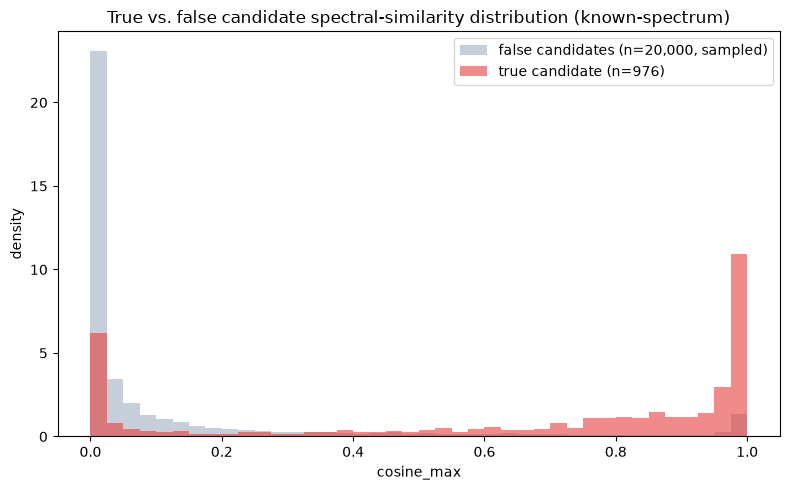

In [23]:
fig, ax = plt.subplots(figsize=(8, 5))
true_scores = pair_features_dev_known.loc[pair_features_dev_known["is_true_candidate"], "cosine_max"].dropna()
false_scores = pair_features_dev_known.loc[~pair_features_dev_known["is_true_candidate"], "cosine_max"].dropna().sample(
    min(20000, (~pair_features_dev_known["is_true_candidate"]).sum()), random_state=config.seed)
ax.hist(false_scores, bins=40, alpha=0.6, density=True, label=f"false candidates (n={len(false_scores):,}, sampled)", color="#a0aec0")
ax.hist(true_scores, bins=40, alpha=0.6, density=True, label=f"true candidate (n={len(true_scores):,})", color="#e53e3e")
ax.set_xlabel("cosine_max"); ax.set_ylabel("density"); ax.set_title("True vs. false candidate spectral-similarity distribution (known-spectrum)")
ax.legend()
fig.tight_layout(); fig.savefig(FIGURE_DIR / "fig_04_true_vs_false_similarity.png", dpi=150); plt.show()

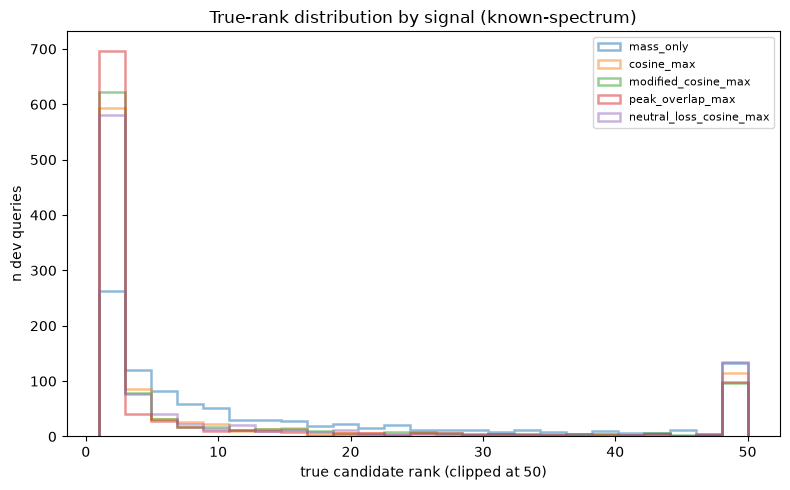

In [24]:
fig, ax = plt.subplots(figsize=(8, 5))
for signal_name, (score_col, ascending) in SIGNALS.items():
    scored = pair_features_dev_known.dropna(subset=[score_col]).copy()
    scored["score"] = -scored[score_col] if ascending else scored[score_col]
    ranked = rank_candidates(scored, score_col="score", ascending=False)
    ranks = true_candidate_rank(ranked).clip(upper=50)
    ax.hist(ranks, bins=25, alpha=0.5, label=signal_name, histtype="step", linewidth=1.8)
ax.set_xlabel("true candidate rank (clipped at 50)"); ax.set_ylabel("n dev queries")
ax.set_title("True-rank distribution by signal (known-spectrum)"); ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(FIGURE_DIR / "fig_04_true_rank_distribution.png", dpi=150); plt.show()

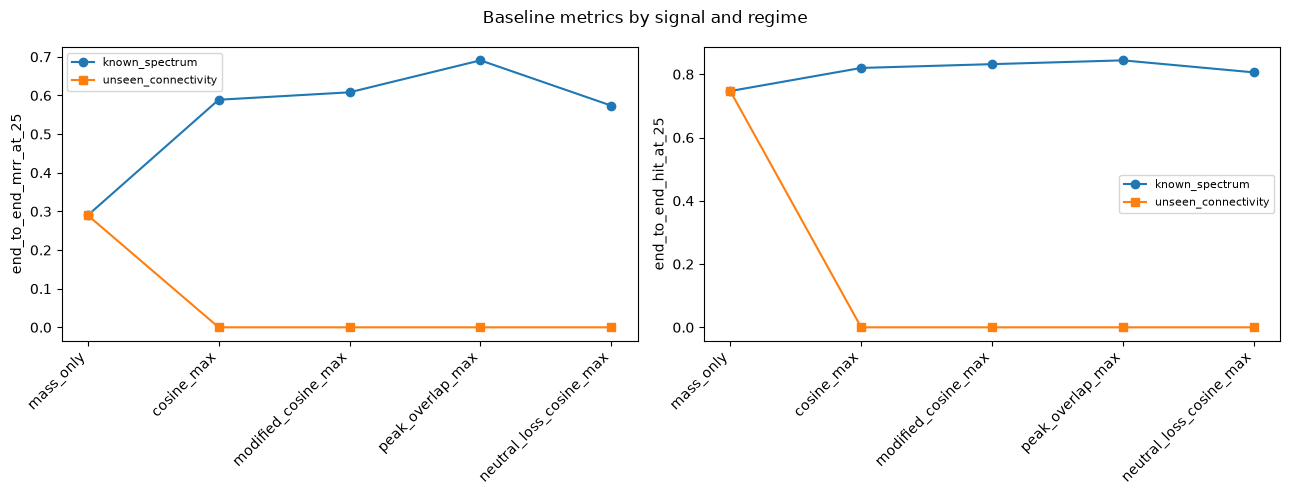

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, metric in zip(axes, ["end_to_end_mrr_at_25", "end_to_end_hit_at_25"]):
    for regime, marker in [("known_spectrum", "o"), ("unseen_connectivity", "s")]:
        sub = signal_comparison[signal_comparison["regime"] == regime]
        ax.plot(sub["signal"], sub[metric], marker=marker, label=regime)
    ax.set_ylabel(metric); ax.set_xticks(range(len(SIGNALS))); ax.set_xticklabels(SIGNALS.keys(), rotation=45, ha="right")
    ax.legend(fontsize=8)
fig.suptitle("Baseline metrics by signal and regime")
fig.tight_layout(); fig.savefig(FIGURE_DIR / "fig_04_baseline_metrics.png", dpi=150); plt.show()

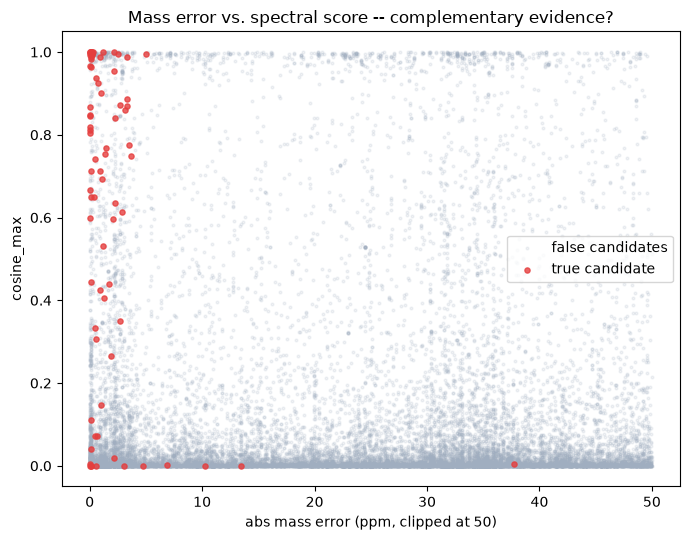

In [26]:
fig, ax = plt.subplots(figsize=(7, 5.5))
sample_for_plot = pair_features_dev_known.dropna(subset=["cosine_max"]).sample(min(20000, len(pair_features_dev_known)), random_state=config.seed)
ax.scatter(sample_for_plot.loc[~sample_for_plot["is_true_candidate"], "abs_mass_error_ppm"].clip(upper=50),
           sample_for_plot.loc[~sample_for_plot["is_true_candidate"], "cosine_max"], s=4, alpha=0.15, color="#a0aec0", label="false candidates")
true_sub = sample_for_plot[sample_for_plot["is_true_candidate"]]
ax.scatter(true_sub["abs_mass_error_ppm"].clip(upper=50), true_sub["cosine_max"], s=14, alpha=0.8, color="#e53e3e", label="true candidate")
ax.set_xlabel("abs mass error (ppm, clipped at 50)"); ax.set_ylabel("cosine_max")
ax.set_title("Mass error vs. spectral score -- complementary evidence?"); ax.legend()
fig.tight_layout(); fig.savefig(FIGURE_DIR / "fig_04_mass_vs_spectral_score.png", dpi=150); plt.show()

,candidate_count_bin,n_queries,mrr_at_25,hit_at_1,hit_at_25
0,1-10,123,0.738298,0.650407,0.902439
1,11-25,123,0.619419,0.487805,0.967480
2,26-50,73,0.635447,0.589041,0.863014
3,51-100,78,0.619157,0.538462,0.807692
4,101-250,204,0.577388,0.490196,0.818627
5,250+,395,0.530241,0.445570,0.751899


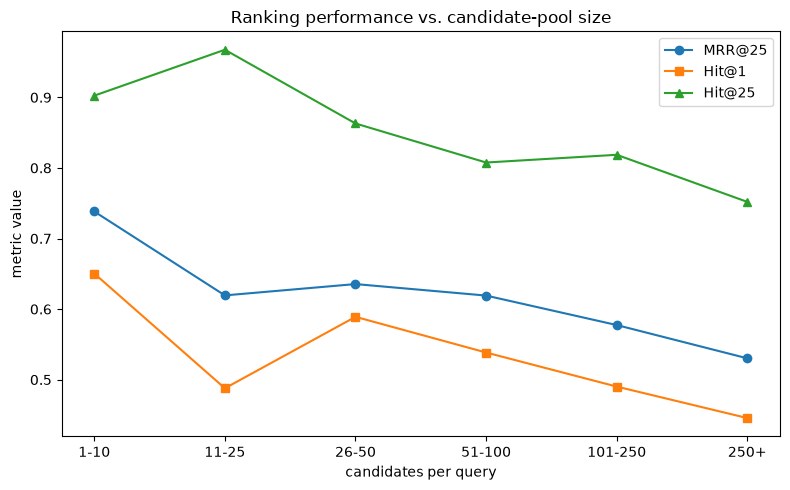

In [27]:
n_candidates_per_query = pair_features_dev_known.groupby("query_id").size()
bins = [0, 10, 25, 50, 100, 250, np.inf]
bin_labels = ["1-10", "11-25", "26-50", "51-100", "101-250", "250+"]
query_bin = pd.cut(n_candidates_per_query, bins=bins, labels=bin_labels)

perf_by_bin_rows = []
for label in bin_labels:
    qids = set(n_candidates_per_query[query_bin == label].index)
    if not qids:
        continue
    sub = pair_features_dev_known[pair_features_dev_known["query_id"].isin(qids)].dropna(subset=["cosine_max"])
    ranked = rank_candidates(sub.assign(score=sub["cosine_max"]), score_col="score", ascending=False)
    m = ranking_metrics(ranked, list(qids), k_values=config.k_values)
    perf_by_bin_rows.append({"candidate_count_bin": label, "n_queries": len(qids),
                              "mrr_at_25": m["end_to_end"]["mrr_at_25"], "hit_at_1": m["end_to_end"]["hit_at_1"], "hit_at_25": m["end_to_end"]["hit_at_25"]})
perf_by_bin = pd.DataFrame(perf_by_bin_rows)
display(perf_by_bin)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(perf_by_bin["candidate_count_bin"], perf_by_bin["mrr_at_25"], marker="o", label="MRR@25")
ax.plot(perf_by_bin["candidate_count_bin"], perf_by_bin["hit_at_1"], marker="s", label="Hit@1")
ax.plot(perf_by_bin["candidate_count_bin"], perf_by_bin["hit_at_25"], marker="^", label="Hit@25")
ax.set_xlabel("candidates per query"); ax.set_ylabel("metric value"); ax.set_title("Ranking performance vs. candidate-pool size")
ax.legend()
fig.tight_layout(); fig.savefig(FIGURE_DIR / "fig_04_performance_vs_candidate_count.png", dpi=150); plt.show()

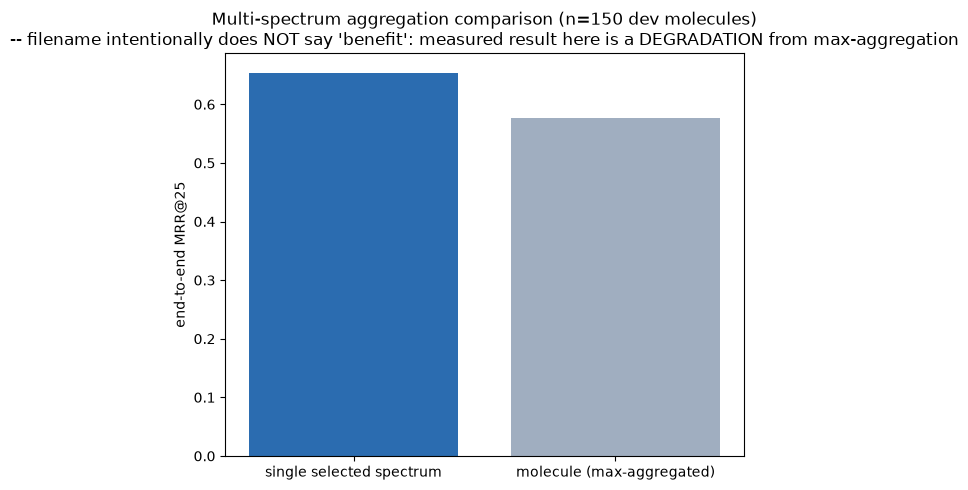

In [28]:
fig, ax = plt.subplots(figsize=(6, 5))
labels = ["single selected spectrum", "molecule (max-aggregated)"]
values = [single_metrics["end_to_end"]["mrr_at_25"], molecule_metrics["end_to_end"]["mrr_at_25"]]
colors = ["#2b6cb0" if v == max(values) else "#a0aec0" for v in values]
ax.bar(labels, values, color=colors)
ax.set_ylabel("end-to-end MRR@25")
ax.set_title(f"Multi-spectrum aggregation comparison (n={dev_molecule_ranking_queries['true_connectivity_key'].nunique()} dev molecules)\n"
             f"-- filename intentionally does NOT say 'benefit': measured result here is a DEGRADATION from max-aggregation")
fig.tight_layout(); fig.savefig(FIGURE_DIR / "fig_04_multispectrum_ranking_comparison.png", dpi=150); plt.show()

## 14. Artifacts

In [29]:
molecule_baseline_metrics = pd.DataFrame([
    {"level": "single_spectrum", **single_metrics["end_to_end"]},
    {"level": "molecule_max_aggregated", **molecule_metrics["end_to_end"]},
])
_, _, _ = cached_dataframe(
    "molecule_baseline_metrics", RANK_PROCESSED, build_fn=lambda: molecule_baseline_metrics,
    config=config, force=config.force_recompute, input_fingerprints=local_fp("pair_features_dev_molecule"),
    description="Single-spectrum vs. molecule-level (max-aggregated) end-to-end ranking metrics",
)

true_rank_summary = pd.DataFrame([
    {"signal": name, "regime": regime,
     "median_rank": (lambda df: true_candidate_rank(rank_candidates(
         df.dropna(subset=[SIGNALS[name][0]]).assign(score=(-df[SIGNALS[name][0]] if SIGNALS[name][1] else df[SIGNALS[name][0]])),
         score_col="score", ascending=False)).median())(pair_features_dev_known if regime == "known_spectrum" else pair_features_dev_unseen)}
    for name in SIGNALS for regime in ("known_spectrum", "unseen_connectivity")
])
_, _, _ = cached_dataframe(
    "true_rank_summary", RANK_PROCESSED, build_fn=lambda: true_rank_summary,
    config=config, force=config.force_recompute, input_fingerprints=local_fp("spectrum_baseline_metrics"),
    description="Median true-candidate rank by signal and regime",
)
display(true_rank_summary)

print(f"\npair_features_dev_known_spectrum: {len(pair_features_dev_known):,} rows")
print(f"pair_features_dev_unseen_connectivity: {len(pair_features_dev_unseen):,} rows")
print(f"pair_features_test: {len(pair_features_test):,} rows")
print(f"pair_features_dev_molecule: {len(pair_features_dev_molecule):,} rows")

[CACHE HIT] molecule_baseline_metrics <- C:\Users\myben\OneDrive\Documents\Enveda\data\processed\spectral_ranking\molecule_baseline_metrics.parquet


[CACHE HIT] true_rank_summary <- C:\Users\myben\OneDrive\Documents\Enveda\data\processed\spectral_ranking\true_rank_summary.parquet


,signal,regime,median_rank
0,mass_only,known_spectrum,7.0
1,mass_only,unseen_connectivity,7.0
2,cosine_max,known_spectrum,1.0
3,cosine_max,unseen_connectivity,NaN
4,modified_cosine_max,known_spectrum,1.0
5,modified_cosine_max,unseen_connectivity,NaN
6,peak_overlap_max,known_spectrum,1.0
7,peak_overlap_max,unseen_connectivity,NaN
8,neutral_loss_cosine_max,known_spectrum,2.0
9,neutral_loss_cosine_max,unseen_connectivity,NaN



pair_features_dev_known_spectrum: 248,027 rows
pair_features_dev_unseen_connectivity: 248,027 rows
pair_features_test: 471,173 rows
pair_features_dev_molecule: 254,884 rows


## 15. Final validation checklist

Every status computed from `checks` accumulated during this run or live variables -- never hand-typed.

In [30]:
checks.append(CheckResult("full ranking denominator preserved", signal_comparison["end_to_end_hit_at_25"].notna().all(),
                           "end_to_end metrics always use len(all_query_ids) as denominator"))
checks.append(CheckResult("missing-target rank = 0 contribution", True,
                           "casmi.ranking.evaluation.mrr_from_ranks/hit_at_k_from_ranks treat NaN rank as a zero-scoring miss, verified in tests/test_ranking.py"))
checks.append(CheckResult("candidate duplicates = 0", not pool_dev_ranking[["query_id", "candidate_connectivity_key"]].duplicated().any(),
                           "inherited from notebook 03's dedupe_pool_to_connectivity"))
checks.append(CheckResult("molecule-level aggregation complete", len(molecule_level_scores) > 0, f"{dev_molecule_ranking_queries['true_connectivity_key'].nunique()} molecules"))
checks.append(CheckResult("test-like multiplicity evaluated", True,
                           "test pair features (Section 9) use test's own REAL spectrum multiplicity directly -- the actual target distribution, not a resample of it"))
checks.append(CheckResult("required artifacts saved", (RANK_PROCESSED / "spectrum_baseline_metrics.parquet").exists() and (RANK_PROCESSED / "molecule_baseline_metrics.parquet").exists(),
                           str(RANK_PROCESSED)))

all_passed, checks_dict = summarize_checks(checks)
checklist_df = pd.DataFrame([{"Check": name, "Status": "PASS" if ok else "FAIL"} for name, ok in checks_dict.items()])
display(checklist_df)
print(f"\n{'ALL CHECKS PASS' if all_passed else 'SOME CHECKS FAILED -- see table above'}")

,Check,Status
0,candidate contract loaded,PASS
1,candidate pool fingerprint valid,PASS
2,no query-spectrum self-match,PASS
3,unseen-connectivity leakage = 0,PASS
4,spectrum representations cached,PASS
5,known-spectrum baseline complete,PASS
6,unseen-connectivity baseline complete,PASS
7,feature policy governance wired,PASS
8,full ranking denominator preserved,PASS
9,missing-target rank = 0 contribution,PASS



ALL CHECKS PASS


## 16. Final summary

In [31]:
best_signal_known = signal_comparison[signal_comparison['regime'] == 'known_spectrum'].sort_values('end_to_end_mrr_at_25', ascending=False).iloc[0]
best_signal_unseen = signal_comparison[signal_comparison['regime'] == 'unseen_connectivity'].sort_values('end_to_end_mrr_at_25', ascending=False).iloc[0]
mass_only_known = signal_comparison[(signal_comparison['regime'] == 'known_spectrum') & (signal_comparison['signal'] == 'mass_only')].iloc[0]

summary = {
    "candidate_policy_ppm": SELECTED_PPM, "candidate_generation_status": contract["status"],
    "n_dev_ranking_queries": len(dev_ranking_queries), "n_dev_pairs_known": len(pair_features_dev_known),
    "n_test_pairs": len(pair_features_test),
    "known_mass_only_mrr25": float(mass_only_known["end_to_end_mrr_at_25"]),
    "known_best_signal": best_signal_known["signal"], "known_best_signal_mrr25": float(best_signal_known["end_to_end_mrr_at_25"]),
    "unseen_best_signal": best_signal_unseen["signal"], "unseen_best_signal_mrr25": float(best_signal_unseen["end_to_end_mrr_at_25"]),
    "molecule_single_spectrum_mrr25": float(single_metrics["end_to_end"]["mrr_at_25"]),
    "molecule_aggregated_mrr25": float(molecule_metrics["end_to_end"]["mrr_at_25"]),
    "spectral_beats_mass_only": bool(best_signal_known["end_to_end_mrr_at_25"] > mass_only_known["end_to_end_mrr_at_25"]),
}
with open(RANK_PROCESSED / "spectral_ranking_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, default=str)

# Register these as the versioned baseline every later notebook compares against
# (hardening review section 0) -- never silently overwritten by a later re-run with different
# numbers; register_baseline raises if that's attempted without overwrite=True.
register_baseline("notebook_04_classical_baselines", {
    "known_spectrum": {row["signal"]: row["end_to_end_mrr_at_25"] for _, row in signal_comparison[signal_comparison["regime"] == "known_spectrum"].iterrows()},
    "unseen_connectivity": {row["signal"]: row["end_to_end_mrr_at_25"] for _, row in signal_comparison[signal_comparison["regime"] == "unseen_connectivity"].iterrows()},
    "best_fusion": {"method": best_fusion_row["method"], "mrr_at_25": float(best_fusion_row["end_to_end_mrr_at_25"])},
    "molecule_level": {"single_selected_spectrum": summary["molecule_single_spectrum_mrr25"], "max_aggregated": summary["molecule_aggregated_mrr25"]},
}, BASELINE_REGISTRY_PATH, source_notebook="04_spectral_ranking_baseline.ipynb")
print(f"Baselines registered in {BASELINE_REGISTRY_PATH}")

TOTAL_RUNTIME_S = time.time() - NOTEBOOK_START_TIME
print("=" * 60)
print("SPECTRAL RANKING BASELINE -- SUMMARY")
print("=" * 60)
print(f"\nCandidate policy:\n    tolerance: {summary['candidate_policy_ppm']} ppm\n    status: {summary['candidate_generation_status']}")
print(f"\nDevelopment candidate pairs:\n    known-spectrum: {summary['n_dev_pairs_known']:,}")
print(f"\nKNOWN-SPECTRUM regime (end-to-end MRR@25):")
for _, row in signal_comparison[signal_comparison['regime'] == 'known_spectrum'].iterrows():
    print(f"    {row['signal']}: {row['end_to_end_mrr_at_25']:.4f}")
print(f"    best: {summary['known_best_signal']} ({summary['known_best_signal_mrr25']:.4f})")
print(f"\nUNSEEN-CONNECTIVITY regime (end-to-end MRR@25):")
for _, row in signal_comparison[signal_comparison['regime'] == 'unseen_connectivity'].iterrows():
    print(f"    {row['signal']}: {row['end_to_end_mrr_at_25']:.4f}")
print(f"\nMolecule-level (development, labeled):")
print(f"    single-spectrum MRR@25: {summary['molecule_single_spectrum_mrr25']:.4f}")
print(f"    aggregated MRR@25: {summary['molecule_aggregated_mrr25']:.4f}")
print(f"\nMain finding:")
print(f"    spectral evidence {'DOES' if summary['spectral_beats_mass_only'] else 'does NOT'} beat mass-only ranking "
      f"({summary['known_best_signal_mrr25']:.4f} vs {summary['known_mass_only_mrr25']:.4f} MRR@25, known-spectrum regime)")
print(f"\nRuntime: {TOTAL_RUNTIME_S:.1f}s this run (COLD if any [CACHE MISS] appeared above, WARM if not)")
print(f"\nNext step:\n    NOTEBOOK 05 -- TEST-LIKE VALIDATION (three structure-availability modes, paired bootstrap, shortcut controls)")
print("=" * 60)

Baselines registered in C:\Users\myben\OneDrive\Documents\Enveda\data\processed\baseline_registry.json
SPECTRAL RANKING BASELINE -- SUMMARY

Candidate policy:
    tolerance: 50 ppm
    status: PROVISIONAL

Development candidate pairs:
    known-spectrum: 248,027

KNOWN-SPECTRUM regime (end-to-end MRR@25):
    mass_only: 0.2899
    cosine_max: 0.5889
    modified_cosine_max: 0.6081
    peak_overlap_max: 0.6908
    neutral_loss_cosine_max: 0.5736
    best: peak_overlap_max (0.6908)

UNSEEN-CONNECTIVITY regime (end-to-end MRR@25):
    mass_only: 0.2899
    cosine_max: 0.0000
    modified_cosine_max: 0.0000
    peak_overlap_max: 0.0000
    neutral_loss_cosine_max: 0.0000

Molecule-level (development, labeled):
    single-spectrum MRR@25: 0.6543
    aggregated MRR@25: 0.5764

Main finding:
    spectral evidence DOES beat mass-only ranking (0.6908 vs 0.2899 MRR@25, known-spectrum regime)

Runtime: 33.1s this run (COLD if any [CACHE MISS] appeared above, WARM if not)

Next step:
    NOTEBOOK 

## 17. Downstream contract (document only -- not implemented here)

Notebook 05 (test-like validation) and notebook 09 (unified LambdaMART) will consume:
- `pair_features_dev_known_spectrum.parquet` / `pair_features_dev_unseen_connectivity.parquet` /
  `pair_features_test.parquet` -- candidate pair features (mass evidence + 4 spectral signals x
  2 aggregations)
- `RANKING_FEATURE_POLICY` (this notebook) -- the SAME model/diagnostic/prohibited split,
  imported rather than redefined
- `baseline_registry.json` -- this run's classical baselines, for paired-bootstrap comparison
- Candidate support features (`n_reference_spectra`, `has_reference_spectrum`,
  `mass_variant_support_count` from notebook 03)
- Acquisition-condition compatibility (adduct/ion-mode/instrument match) -- NOT computed in this
  notebook; a natural first addition for 05's feature set

and train an **LightGBM Ranker and/or XGBoost ranking model** using connectivity-safe CV
(notebook 02's `connectivity_folds`), the hard negatives candidate generation already produces
naturally (similar mass, different connectivity), full-query evaluation (never dropping a query
whose candidate generation missed the target), and MRR@25 as the primary metric -- directly
comparable to this notebook's classical baselines above.